In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dna = "GCTAGCTAACGTACGTAGCTTAGCACGATCGTAGCTAGCTACG"
BASES = ['A', 'C', 'G', 'T']

In [9]:
FREQ = {x: {y: 0 for y in BASES} for x in BASES}

for i in range(len(dna) - 1):
    first = dna[i]
    second = dna[i + 1]
    if first in BASES and second in BASES:
        FREQ[first][second] += 1
    else:
        print(f"Invalid base: {first} or {second}.")

In [10]:
PROB = {x: {} for x in BASES}
for x in BASES:
    count = sum(FREQ[x].values())
    for y in BASES:
        PROB[x][y] = FREQ[x][y] / count if count > 0 else 0.0

matrix = pd.DataFrame(PROB)
print("Probability Matrix:")
print(matrix)

Probability Matrix:
          A         C    G    T
A  0.090909  0.090909  0.1  0.8
C  0.363636  0.000000  0.6  0.1
G  0.454545  0.454545  0.0  0.0
T  0.090909  0.454545  0.3  0.1


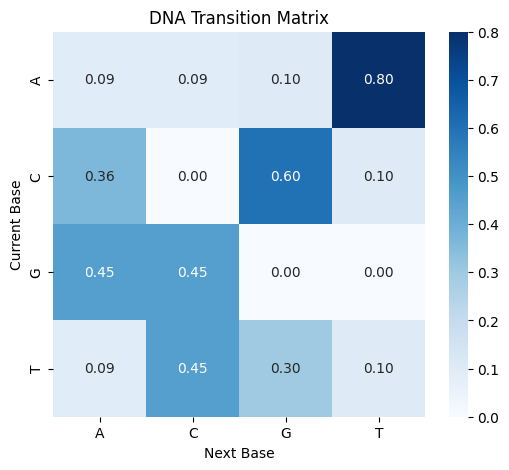

In [11]:
plt.figure(figsize=(6, 5))
sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues")
plt.xlabel("Next Base")
plt.ylabel("Current Base")
plt.title("DNA Transition Matrix")
plt.show()

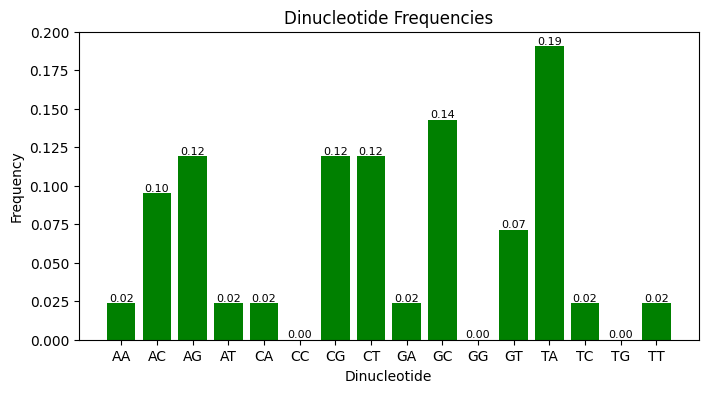

In [12]:
total = len(dna) - 1
PAIRS = {f"{x}{y}": FREQ[x][y] / total for x in BASES for y in BASES}

labels = sorted(PAIRS.keys())
values = [PAIRS[p] for p in labels]
plt.figure(figsize=(8, 4))
bars = plt.bar(labels, values, color="green")
plt.xlabel("Dinucleotide")
plt.ylabel("Frequency")
plt.title("Dinucleotide Frequencies")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}", ha="center", va="bottom", fontsize=8)
plt.show()